# IEEE-CIS Fraud Detection - Model Inference

## 1. Load best Pipeline from MLflow Model Registry

In [6]:
!pip install numpy pandas matplotlib seaborn scikit-learn mlflow dagshub
import os, gc, pandas as pd, numpy as np
import mlflow, mlflow.sklearn, dagshub
import warnings; warnings.filterwarnings('ignore')

REPO_OWNER = "rkvit23"
REPO_NAME  = "ML-HW2"
dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/rkvit23/ML-HW2.mlflow")


REGISTERED_NAME = "IEEE_Fraud_LightGBM"  
MODEL_URI       = f"models:/{REGISTERED_NAME}/latest"

print(f"Loading {MODEL_URI} from MLflow ...")
pipeline = mlflow.sklearn.load_model(MODEL_URI)
print("Loaded:", type(pipeline))


Initialized MLflow to track repo "rkvit23/ML-HW2"

Repository rkvit23/ML-HW2 initialized!

Loading models:/IEEE_Fraud_LightGBM/latest from MLflow ...


Loaded: <class 'sklearn.pipeline.Pipeline'>


## 2. Predict on raw test set

In [7]:
DATA_DIR = "/kaggle/input/competitions/ieee-fraud-detection"   # change to "/kaggle/input/ieee-fraud-detection" on Kaggle

print("Loading raw test data...")
test_tx = pd.read_csv(os.path.join(DATA_DIR, "test_transaction.csv"))
test_id = pd.read_csv(os.path.join(DATA_DIR, "test_identity.csv"))
test_id.columns = [c.replace('-', '_') for c in test_id.columns]
test = test_tx.merge(test_id, on="TransactionID", how="left")
del test_tx, test_id; gc.collect()

test_ids = test["TransactionID"].copy()
X_raw    = test.drop(columns=["TransactionID"])
print(f"Raw test shape: {X_raw.shape}")

# The pipeline includes ALL preprocessing -> preds in one call
print("Predicting...")
preds = pipeline.predict_proba(X_raw)[:, 1]
print(f"Done. mean P(fraud) = {preds.mean():.5f}, min={preds.min():.5f}, max={preds.max():.5f}")


Loading raw test data...
Raw test shape: (506691, 432)
Predicting...
Done. mean P(fraud) = 0.03949, min=0.00000, max=0.99999


## 3. Generate `submission.csv`

In [8]:
submission = pd.DataFrame({"TransactionID": test_ids, "isFraud": preds})
submission.to_csv("submission.csv", index=False)
print("submission.csv saved:", submission.shape)
submission.head()


submission.csv saved: (506691, 2)


,TransactionID,isFraud
0,3663549,0.000077
1,3663550,0.000849
2,3663551,0.000068
3,3663552,0.000705
4,3663553,0.000963


## 4. Sanity-check predictions

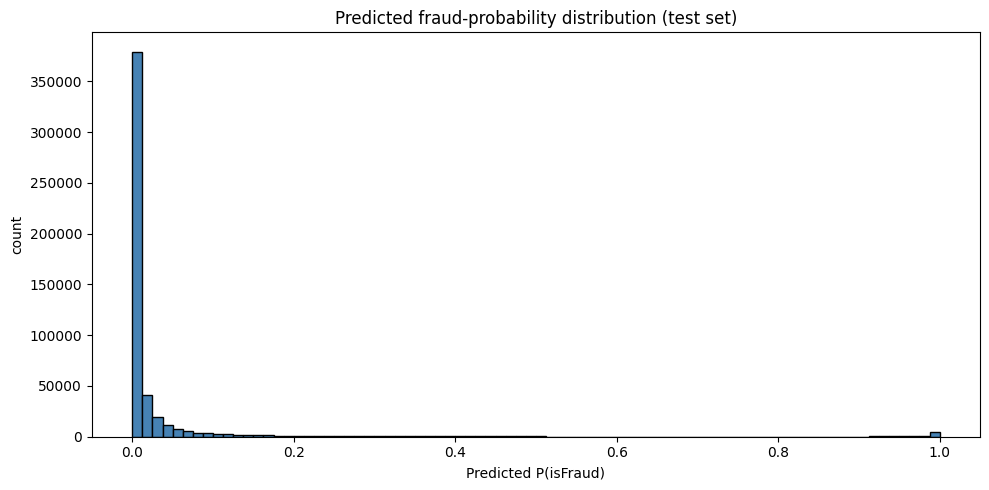

Top-10 highest-risk transactions:
 TransactionID  isFraud
       3688827 0.999991
       3966204 0.999989
       3688838 0.999989
       3697930 0.999988
       3895799 0.999988
       3966206 0.999987
       3688816 0.999986
       3688934 0.999985
       3688892 0.999985
       3688946 0.999985


In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(preds, bins=80, color='steelblue', edgecolor='black')
ax.set_xlabel('Predicted P(isFraud)'); ax.set_ylabel('count')
ax.set_title('Predicted fraud-probability distribution (test set)')
plt.tight_layout(); plt.show()

print("Top-10 highest-risk transactions:")
print(submission.sort_values('isFraud', ascending=False).head(10).to_string(index=False))
